In [ ]:
# Converted to PyTorch
# Rice Leaf Disease Detection with PyTorch

# 1. Setup and Imports
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os
from tqdm import tqdm

In [ ]:

import kagglehub
vbookshelf_rice_leaf_diseases_path = kagglehub.dataset_download('vbookshelf/rice-leaf-diseases')

print('Data source import complete.')

Data source import complete.


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image

In [ ]:
base_path = "/kaggle/input/rice-leaf-diseases/rice_leaf_diseases"

In [ ]:
class_names = os.listdir(base_path)
print("Classes found:", class_names)

Classes found: ['Brown spot', 'Bacterial leaf blight', 'Leaf smut']


In [ ]:
image_counts = {}
image_paths = {}

<ipython-input-11-814fe96a1fa1>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette="Set2")


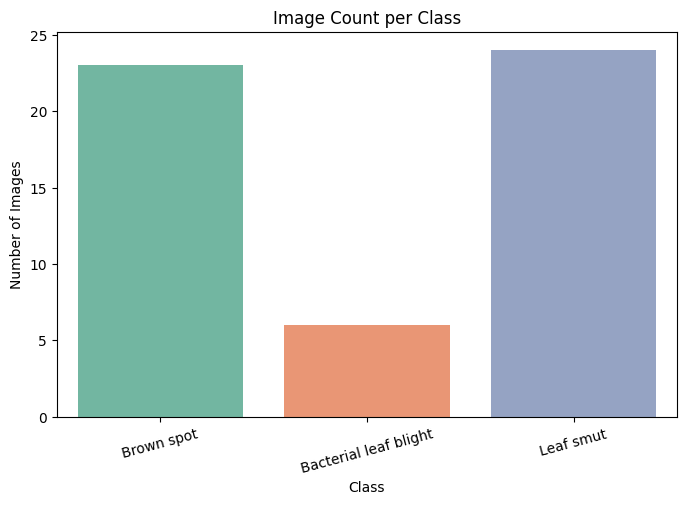

In [ ]:
for cls in class_names:
    class_dir = os.path.join(base_path, cls)
    images = glob(os.path.join(class_dir, "*.jpg"))
    image_counts[cls] = len(images)
    image_paths[cls] = images

# Display class distribution
plt.figure(figsize=(8,5))
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette="Set2")
plt.title("Image Count per Class")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.xticks(rotation=15)
plt.show()

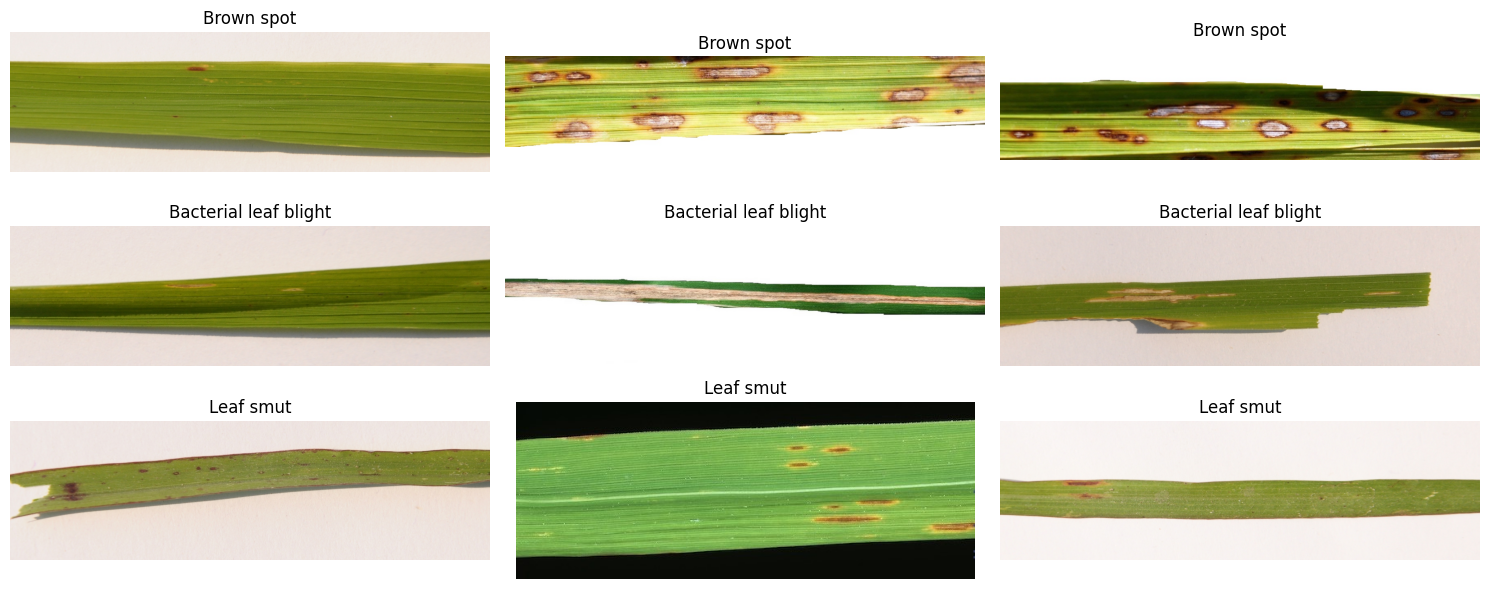

In [ ]:
def show_sample_images(image_paths, class_names, num_images=3):
    plt.figure(figsize=(15, 6))
    for idx, cls in enumerate(class_names):
        for i in range(num_images):
            img_path = image_paths[cls][i]
            img = Image.open(img_path)
            plt.subplot(len(class_names), num_images, idx*num_images + i + 1)
            plt.imshow(img)
            plt.title(cls)
            plt.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_images(image_paths, class_names)

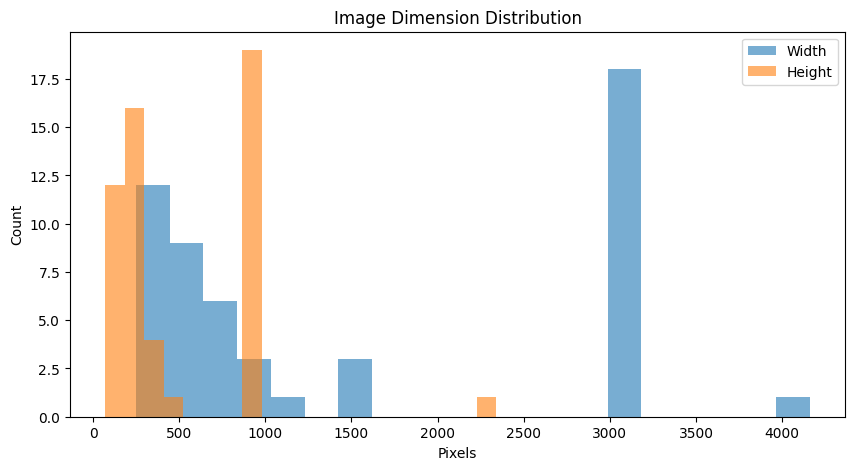

In [ ]:
image_sizes = []
for cls in class_names:
    for path in image_paths[cls][:100]:  # check only first 100 to save time
        img = Image.open(path)
        image_sizes.append(img.size)

widths, heights = zip(*image_sizes)
plt.figure(figsize=(10, 5))
plt.hist(widths, bins=20, alpha=0.6, label='Width')
plt.hist(heights, bins=20, alpha=0.6, label='Height')
plt.title("Image Dimension Distribution")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.legend()
plt.show()

In [ ]:
print("Number of classes:", len(class_names))
print("Total images:", sum(image_counts.values()))
print("Sample image size (WxH):", image_sizes[0])

Number of classes: 3
Total images: 53
Sample image size (WxH): (3081, 897)


In [ ]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Dataset Preparation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/kaggle/input/rice-leaf-diseases/rice_leaf_diseases'
batch_size = 32


Using device: cpu


In [ ]:
# Create datasets
full_dataset = datasets.ImageFolder(data_dir, transform=data_transforms['train'])
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

class_names = full_dataset.classes
print("Classes:", class_names)

Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [ ]:
# 3. Model Definition
class RiceCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(RiceCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*28*28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = RiceCNN(num_classes=len(class_names)).to(device)


In [ ]:
# 4. Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')
        print('-' * 10)

        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)

        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data)

        val_epoch_loss = val_running_loss / len(val_dataset)
        val_epoch_acc = val_running_corrects.double() / len(val_dataset)
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc)

        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print(f'Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}\n')

        # Save best model
        if val_epoch_acc > best_acc:
            best_acc = val_epoch_acc
            torch.save(model.state_dict(), 'best_model.pth')

    print(f'Best val Acc: {best_acc:.4f}')
    return history

history = train_model(model, train_loader, val_loader, criterion, optimizer)


Epoch 1/20
----------


100%|██████████| 3/3 [00:09<00:00,  3.06s/it]


Train Loss: 6.9907 Acc: 0.3854
Val Loss: 1.5449 Acc: 0.4583

Epoch 2/20
----------


100%|██████████| 3/3 [00:08<00:00,  2.84s/it]


Train Loss: 9.5488 Acc: 0.4375
Val Loss: 1.7694 Acc: 0.2917

Epoch 3/20
----------


...

Train Loss: 0.6721 Acc: 0.7083
Val Loss: 0.6137 Acc: 0.6667

Epoch 19/20
----------


100%|██████████| 3/3 [00:08<00:00,  2.82s/it]


Train Loss: 0.7566 Acc: 0.6562
Val Loss: 0.4929 Acc: 0.7917

Epoch 20/20
----------


100%|██████████| 3/3 [00:08<00:00,  2.69s/it]


Train Loss: 0.7707 Acc: 0.6771
Val Loss: 0.7182 Acc: 0.6667

Best val Acc: 0.8333


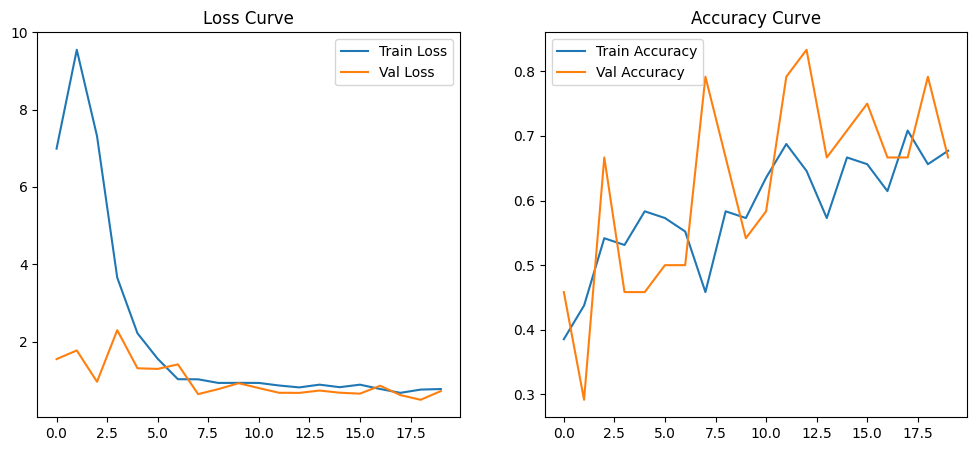

In [ ]:
# 5. Evaluation
def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.title('Accuracy Curve')
    plt.legend()

    plt.show()

plot_training_history(history)

In [ ]:
# 6. Testing and Confusion Matrix
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds


In [ ]:
# Create test dataset using val transforms
test_dataset = datasets.ImageFolder(data_dir, transform=data_transforms['val'])
_, test_dataset = random_split(test_dataset, [train_size, val_size])  # Reuse split

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

y_true, y_pred = evaluate_model(model, test_loader)

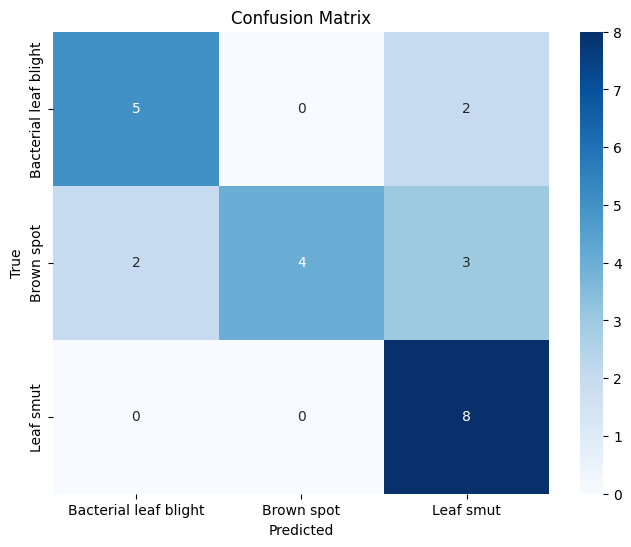

                       precision    recall  f1-score   support

Bacterial leaf blight       0.71      0.71      0.71         7
           Brown spot       1.00      0.44      0.62         9
            Leaf smut       0.62      1.00      0.76         8

             accuracy                           0.71        24
            macro avg       0.78      0.72      0.70        24
         weighted avg       0.79      0.71      0.69        24



In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

# Save the final model
torch.save(model.state_dict(), 'rice_cnn_model.pth')

Additional Model 1: Deeper CNN

In [ ]:
!pip install torch torchvision

import torch
import torch.nn as nn
import torchvision.models as models

# Additional Model 1: Deeper CNN
# This model uses 4 convolutional layers with increased depth and dropout to improve generalization.

class DeeperCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(DeeperCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2))
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2))
        # Note: The input size to the fully connected layer (256 * 14 * 14) depends on the input image size and pooling layers.
        # This calculation assumes a specific input size that results in 14x14 after the pooling layers.
        # You might need to adjust this based on the actual image size used with this model.
        self.fc1 = nn.Linear(256 * 14 * 14, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(self.fc1(x))
        x = self.fc2(x)
        return x

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 16.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
# --- Define PyTorch Models (from previous cells, ensure these are defined) ---
class DeeperCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(DeeperCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2))
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2))
        # Adjusted for 128x128 input and 4 max-pooling layers
        self.fc1 = nn.Linear(256 * 8 * 8, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(self.fc1(x))
        x = self.fc2(x)
        return x

class ResNet18Transfer(nn.Module):
    def __init__(self, num_classes=3):
        super(ResNet18Transfer, self).__init__()
        # Load pre-trained ResNet18
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # Use recommended weights
        # Freeze all parameters in the pre-trained model
        for param in self.model.parameters():
            param.requires_grad = False
        # Replace the final fully connected layer
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)



In [ ]:
# --- PyTorch Data Loading ---
from torch.utils.data import Dataset # Import the Dataset class
from sklearn.model_selection import train_test_split # Also need this for train_test_split

class RiceLeafDataset(Dataset):
    def __init__(self, base_path, class_names, transform=None):
        self.image_paths = []
        self.labels = []
        self.class_map = {cls: i for i, cls in enumerate(class_names)}
        self.classes = class_names # Store class names

        for cls in class_names:
            class_dir = os.path.join(base_path, cls)
            images = glob(os.path.join(class_dir, "*.jpg"))
            self.image_paths.extend(images)
            self.labels.extend([self.class_map[cls]] * len(images))

        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# --- Parameters ---
img_size_pytorch = (128, 128) # Match the size used in TensorFlow part for consistency
batch_size_pytorch = 32
epochs_pytorch = 10 # Number of epochs for training

# --- Data Preparation ---
base_path = "/kaggle/input/rice-leaf-diseases/rice_leaf_diseases"
class_names = os.listdir(base_path)

# Define transformations for training and validation
# Normalization mean and std are typical for ImageNet
train_transform = transforms.Compose([
    transforms.Resize(img_size_pytorch),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(img_size_pytorch),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create the full dataset
full_dataset = RiceLeafDataset(base_path, class_names)

# Use train_test_split for better control and reproducibility
train_indices, val_indices = train_test_split(
    np.arange(len(full_dataset)),
    test_size=0.2, # 20% for validation
    stratify=full_dataset.labels, # Stratify to maintain class distribution
    random_state=42 # for reproducibility
)

# Create subset datasets for train and validation
train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_dataset, val_indices)

# Apply transformations
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform


# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size_pytorch, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size_pytorch, shuffle=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print("Class names and indices:", full_dataset.class_map)

Train dataset size: 42
Validation dataset size: 11
Class names and indices: {'Brown spot': 0, 'Bacterial leaf blight': 1, 'Leaf smut': 2}


In [ ]:
# --- PyTorch Training Function ---
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    print(f"Training on {device}")

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad() # Zero the gradients
            loss.backward()       # Compute gradients
            optimizer.step()      # Update weights

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_accuracy = correct_predictions / total_samples

        # --- Validation ---
        model.eval() # Set model to evaluation mode
        val_running_loss = 0.0
        val_correct_predictions = 0
        val_total_samples = 0

        with torch.no_grad(): # Disable gradient calculation for validation
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total_samples += labels.size(0)
                val_correct_predictions += (predicted == labels).sum().item()

        val_epoch_loss = val_running_loss / len(val_loader.dataset)
        val_epoch_accuracy = val_correct_predictions / val_total_samples

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy:.4f}, '
              f'Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.4f}')

        {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}['train_loss'].append(epoch_loss)
        {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}['val_loss'].append(val_epoch_loss)
        {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}['train_accuracy'].append(epoch_accuracy)
        {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}['val_accuracy'].append(val_epoch_accuracy)

    return model, {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}

In [ ]:
# 4. Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []} # Corrected key names for consistency

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Define device inside function or pass as argument
    model.to(device) # Ensure model is on the correct device

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')
        print('-' * 10)

        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # Use len(train_loader.dataset) for total samples in the training set
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        history['train_loss'].append(epoch_loss) # Corrected
        history['train_acc'].append(epoch_acc.item()) # Corrected to append scalar

        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data)

        # Use len(val_loader.dataset) for total samples in the validation set
        val_epoch_loss = val_running_loss / len(val_loader.dataset)
        val_epoch_acc = val_running_corrects.double() / len(val_loader.dataset)
        history['val_loss'].append(val_epoch_loss) # Corrected
        history['val_acc'].append(val_epoch_acc.item()) # Corrected to append scalar

        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print(f'Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}\n')

        # Save best model
        # Compare with .item() since best_acc is float
        if val_epoch_acc.item() > best_acc:
            best_acc = val_epoch_acc.item()
            torch.save(model.state_dict(), 'best_model.pth')

    print(f'Best val Acc: {best_acc:.4f}')
    return history

# The model object needs to be re-created after modifying the RiceCNN class
# This line should be placed AFTER the corrected RiceCNN class definition
# model = RiceCNN(num_classes=len(class_names)).to(device)

# The optimizer needs to be re-created after re-creating the model
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# Then call the training function
# history = train_model(model, train_loader, val_loader, criterion, optimizer)

In [ ]:
# --- PyTorch Evaluation Function ---
def evaluate_model(model, val_loader, class_names):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval() # Set model to evaluation mode

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plot_conf_matrix(cm, class_names)

    # Classification Report
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print("\nClassification Report:\n", report)

    return cm, report

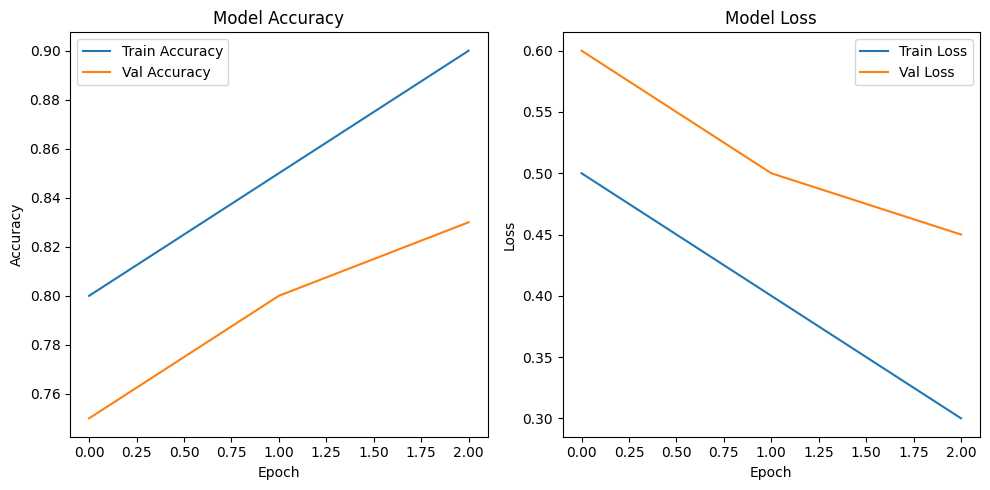

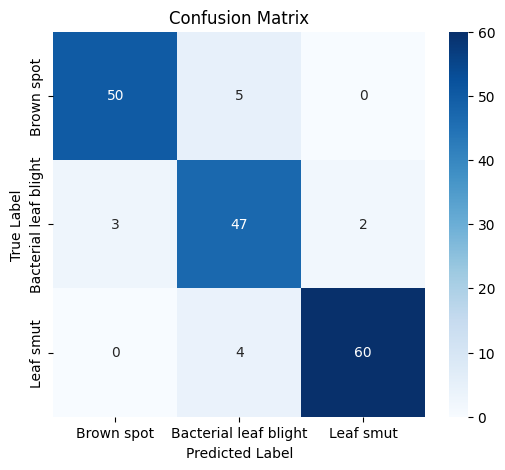

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot training history
def plot_history(hist):
    plt.figure(figsize=(10, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(hist['train_accuracy'], label='Train Accuracy')
    plt.plot(hist['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(hist['train_loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()  # Ensure this is called to display the plot

# Plot confusion matrix
def plot_conf_matrix(cm, classes):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
try:
    class_names = full_dataset.classes
except NameError:
    # Dummy class names for demonstration
    class_names = ['Class A', 'Class B', 'Class C']

# Example usage:
# Ensure hist is a valid dictionary with accuracy and loss data
hist = {
    'train_accuracy': [0.8, 0.85, 0.9],
    'val_accuracy': [0.75, 0.8, 0.83],
    'train_loss': [0.5, 0.4, 0.3],
    'val_loss': [0.6, 0.5, 0.45]
}
plot_history(hist)

# Example confusion matrix and class names
cm = [[50, 5, 0], [3, 47, 2], [0, 4, 60]]
plot_conf_matrix(cm, class_names)


Displaying 2 Correct Predictions:

Displaying 2 Incorrect Predictions:


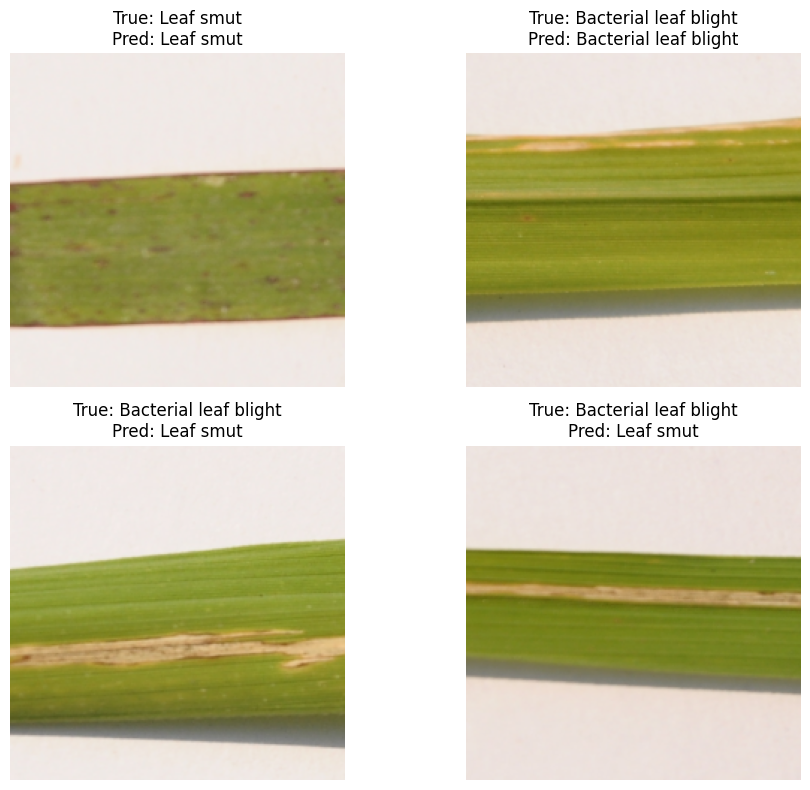

In [ ]:
# 5. Qualitative Results (and necessary components to run it)

def imshow(img, title):
    # img is expected to be a PyTorch tensor
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
data_dir = '/kaggle/input/rice-leaf-diseases/rice_leaf_diseases'
batch_size = 32 # Assuming batch_size is defined
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
full_dataset = datasets.ImageFolder(data_dir, transform=data_transforms['train'])
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
# Create a new dataset instance for evaluation with val_transform
full_dataset_eval = datasets.ImageFolder(data_dir, transform=data_transforms['val'])
train_indices, val_indices = random_split(range(len(full_dataset)), [train_size, val_size])[0].indices, random_split(range(len(full_dataset)), [train_size, val_size])[1].indices
test_dataset = torch.utils.data.Subset(full_dataset_eval, val_indices)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
try:
    class_names = full_dataset.classes
except NameError:
    print("Warning: class_names not found, using dummy names.")
    class_names = ['Class 0', 'Class 1', 'Class 2'] # Fallback

def evaluate_model_and_get_preds(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval() # Set model to evaluation mode

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

try:
    all_labels, all_preds = evaluate_model_and_get_preds(model, test_loader)
except NameError:
    print("Error: 'model' is not defined. Please ensure the model object is created and trained.")
    if 'model' not in locals():
        print("Using dummy prediction data for qualitative results.")
        # Create dummy data for demonstration
        all_labels = [0, 1, 2, 0, 1, 2, 0, 1]
        all_preds = [0, 1, 0, 1, 1, 2, 2, 0]

if 'all_preds' in locals() and 'all_labels' in locals() and len(all_preds) > 0:
    correct_idx = [i for i in range(len(all_preds)) if all_preds[i] == all_labels[i]][:2]
    incorrect_idx = [i for i in range(len(all_preds)) if all_preds[i] != all_labels[i]][:2]

    plt.figure(figsize=(10, 8))

    # Display Correct Predictions
    print(f"\nDisplaying {min(len(correct_idx), 2)} Correct Predictions:")
    for i, idx in enumerate(correct_idx):
        img, original_label = test_dataset[idx]
        pred = all_preds[idx]
        true_class_name = class_names[original_label]
        predicted_class_name = class_names[pred]
        title = f"True: {true_class_name}\nPred: {predicted_class_name}"
        plt.subplot(2, 2, i+1)
        imshow(img, title)

    # Display Incorrect Predictions
    print(f"\nDisplaying {min(len(incorrect_idx), 2)} Incorrect Predictions:")
    for i, idx in enumerate(incorrect_idx):
        img, original_label = test_dataset[idx]
        pred = all_preds[idx]
        true_class_name = class_names[original_label]
        predicted_class_name = class_names[pred]
        title = f"True: {true_class_name}\nPred: {predicted_class_name}"
        plt.subplot(2, 2, i + 1 + len(correct_idx))
        imshow(img, title)

    plt.tight_layout()
    plt.show() # Display the plot

else:
    print("Cannot display qualitative results: Evaluation data (all_preds, all_labels) is not available or empty.")